In [8]:
# Decision Tree Regression Model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [9]:
# Load Dataset
df = pd.read_csv("crop_yield.csv")


In [10]:
# Basic Information
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
df.info()

Dataset Shape: (19689, 10)

First 5 Rows:
           Crop  Crop_Year       Season  State     Area  Production  \
0      Arecanut       1997  Whole Year   Assam  73814.0       56708   
1     Arhar/Tur       1997  Kharif       Assam   6637.0        4685   
2   Castor seed       1997  Kharif       Assam    796.0          22   
3      Coconut        1997  Whole Year   Assam  19656.0   126905000   
4  Cotton(lint)       1997  Kharif       Assam   1739.0         794   

   Annual_Rainfall  Fertilizer  Pesticide        Yield  
0           2051.4  7024878.38   22882.34     0.796087  
1           2051.4   631643.29    2057.47     0.710435  
2           2051.4    75755.32     246.76     0.238333  
3           2051.4  1870661.52    6093.36  5238.051739  
4           2051.4   165500.63     539.09     0.420909  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------ 

In [11]:
# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64


In [12]:
# Check Duplicate Values
print("\nDuplicate Rows:", df.duplicated().sum())



Duplicate Rows: 0


In [13]:
# Remove Duplicate Rows
df = df.drop_duplicates()


In [14]:
# Encode Categorical Columns
le_crop = LabelEncoder()
le_season = LabelEncoder()
le_state = LabelEncoder()

df["Crop"] = le_crop.fit_transform(df["Crop"])
df["Season"] = le_season.fit_transform(df["Season"])
df["State"] = le_state.fit_transform(df["State"])

In [15]:
# Select Features and Target
X = df.drop("Yield", axis=1)
y = df["Yield"]

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("Yield")



Features:
['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide']

Target:
Yield


In [16]:

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (15751, 9)
Testing Data Shape: (3938, 9)


In [17]:
# Decision Tree Model
model = DecisionTreeRegressor(
    random_state=42
)


In [18]:
# Hyperparameter Tuning
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [19]:
# Train Model
grid_search.fit(X_train, y_train)


,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [20]:
# Best Parameters
print("\nBest Parameters:")
print(grid_search.best_params_)


Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [21]:
# Best Model
best_model = grid_search.best_estimator_

# Prediction
y_pred = best_model.predict(X_test)


In [22]:
# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nDecision Tree Regression Results")
print("--------------------------------")
print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)


Decision Tree Regression Results
--------------------------------
Mean Absolute Error : 12.409430598649111
Mean Squared Error  : 107041.13787683845
Root Mean Squared Error : 327.1714197127225
R2 Score : 0.8664056263736887


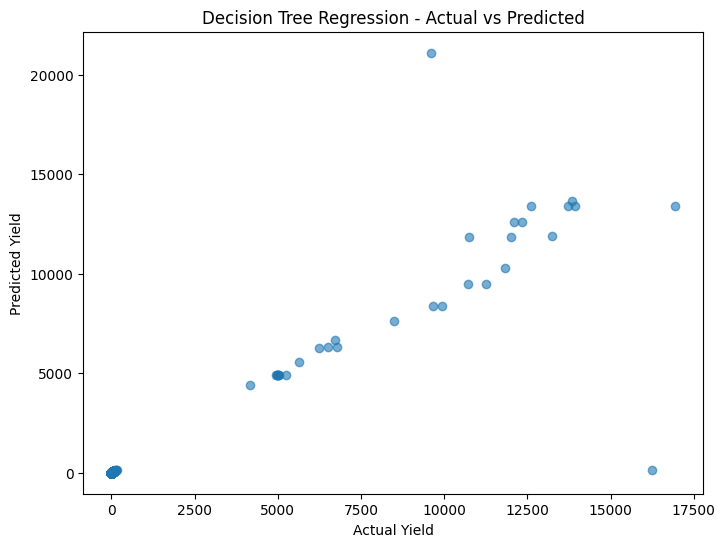

In [23]:
# Actual vs Predicted Graph
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Decision Tree Regression - Actual vs Predicted")

plt.show()

In [24]:
# Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
           Feature  Importance
5       Production    0.723107
4             Area    0.142314
3            State    0.052718
0             Crop    0.036809
8        Pesticide    0.034199
6  Annual_Rainfall    0.005289
7       Fertilizer    0.005004
1        Crop_Year    0.000547
2           Season    0.000013


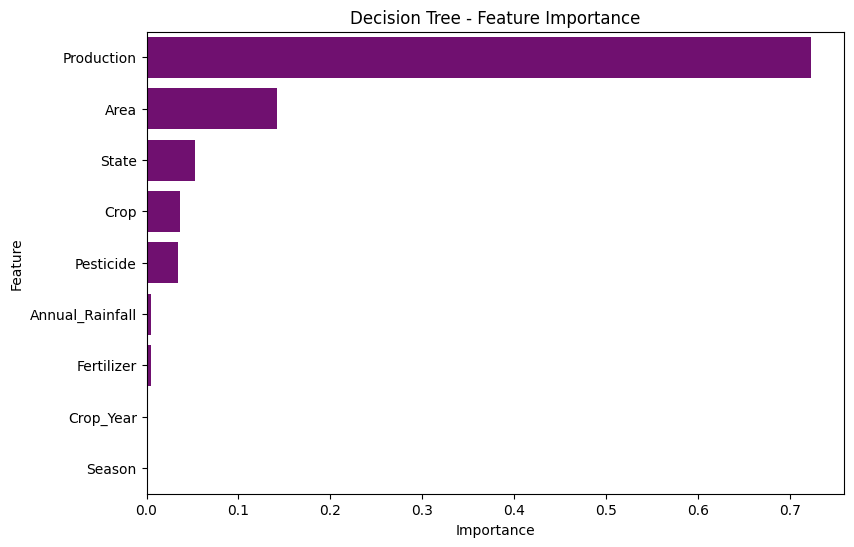

In [ ]:
# Feature Importance Graph
plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",color="purple"
)

plt.title("Decision Tree - Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [27]:
# Final Result
print("\n================================")
print("FINAL RESULT")
print("================================")
print("Best Parameters:", grid_search.best_params_)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

print("\nDecision Tree Regression Completed Successfully.")


FINAL RESULT
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
MAE: 12.409430598649111
MSE: 107041.13787683845
RMSE: 327.1714197127225
R2 Score: 0.8664056263736887

Decision Tree Regression Completed Successfully.


<div align="center">

<!-- 🌈 Animated Title -->
<img src="https://readme-typing-svg.demolab.com?font=Fira+Code&weight=700&size=32&duration=1800&pause=700&color=FF4D6D&center=true&vCenter=true&width=800&lines=%F0%9F%8C%88+THANK+YOU+FOR+VISITING!;%F0%9F%92%9C+THANK+YOU+FOR+EXPLORING+MY+PROJECT!;%F0%9F%9A%80+KEEP+LEARNING+%7C+KEEP+BUILDING!;%E2%9C%A8+SEE+YOU+AGAIN!+%E2%9C%A8" />

<br><br>

<!-- 💖 Colorful Badges -->
<img src="https://img.shields.io/badge/THANK%20YOU-FF4D6D?style=for-the-badge&logo=heart&logoColor=white" />
<img src="https://img.shields.io/badge/KEEP%20LEARNING-845EC2?style=for-the-badge&logo=bookstack&logoColor=white" />
<img src="https://img.shields.io/badge/KEEP%20BUILDING-00C9A7?style=for-the-badge&logo=rocket&logoColor=white" />
<img src="https://img.shields.io/badge/KEEP%20EXPLORING-FFC75F?style=for-the-badge&logo=star&logoColor=white" />

<br><br>

<!-- 🌟 Animated GIF -->
<img src="https://media.giphy.com/media/hvRJCLFzcasrR4ia7z/giphy.gif" width="90"/>

<br>

<h2>💙 Thank You for Your Valuable Time 💙</h2>

<p>
🌸 <b>Code</b> &nbsp; • &nbsp;
🤖 <b>Learn</b> &nbsp; • &nbsp;
📊 <b>Analyze</b> &nbsp; • &nbsp;
🚀 <b>Build</b> &nbsp; • &nbsp;
✨ <b>Innovate</b>
</p>

<br>

<!-- 🌈 Gradient Divider -->
<img src="https://capsule-render.vercel.app/api?type=rect&color=gradient&height=8&section=header" width="85%"/>

<br><br>

<h3>
💜 Every Project Is a Step Forward 💜
</h3>

<p>
<i>Thank you for stopping by and exploring my work! 🌟</i>
</p>

<br>

<!-- 🌊 Colorful Footer -->
<img src="https://capsule-render.vercel.app/api?type=waving&height=160&color=gradient&customColorList=6,11,12,14,16,17&section=footer" width="100%"/>

</div>